# Task 10: Wasserstein GAN with Gradient Penalty (WGAN-GP)

Understand Gradient Penalty calculation for stable GAN training in simple lines.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

### 1. Critic (Discriminator) Model & Gradient Penalty

In [2]:
critic = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1))

# Real and Fake 2D points
real_points = torch.randn(10, 2) + 2.0
fake_points = torch.randn(10, 2) - 2.0

# Interpolated points for Gradient Penalty
alpha = torch.rand(10, 1)
interpolates = (alpha * real_points + (1 - alpha) * fake_points).requires_grad_(True)

# Compute gradients w.r.t interpolated inputs
scores = critic(interpolates)
grads = torch.autograd.grad(scores, interpolates, torch.ones_like(scores), create_graph=True)[0]
gradient_penalty = ((grads.norm(2, dim=1) - 1) ** 2).mean()

print(f'WGAN Gradient Penalty Loss: {gradient_penalty.item():.4f}')

WGAN Gradient Penalty Loss: 0.8248


### 2. Plot Real vs Fake Points

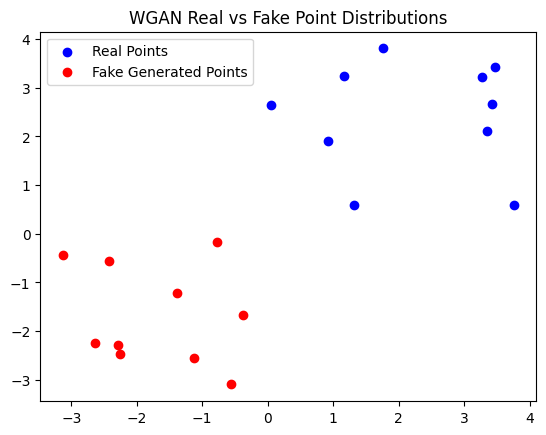

In [3]:
plt.scatter(real_points[:, 0], real_points[:, 1], color='blue', label='Real Points')
plt.scatter(fake_points[:, 0], fake_points[:, 1], color='red', label='Fake Generated Points')
plt.title('WGAN Real vs Fake Point Distributions')
plt.legend()
plt.show()